In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import scipy
from sandbox.jordan5 import setup_device
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import defaultdict


from sandbox.jordan8 import *

import json
import os

In [2]:
from sandbox.plt_dict import matplotlib_update
matplotlib_update()

In [3]:
device = setup_device()

# Running tests

In [8]:
def run_test(model, d, json_filename, matrices_per_class=1000, eps_range=(1e-8, 1)):
    model.eval()

    features = []
    avg_eigenvalues = []
    max_eigenvalues = []
    labels = []
    dists = []
    
    log_eps_min, log_eps_max = np.log(eps_range[0]), np.log(eps_range[1])
    
    # 1. Data Generation
    for max_block_size in range(1, d+1):
        for _ in range(matrices_per_class):
            eps = np.exp(np.random.uniform(log_eps_min, log_eps_max))
            J, S = generate_matrix(d, max_block_size, eps=eps, return_J=True, numpy_float32=True)
            A = np.linalg.inv(S) @ J @ S
            
            features.append(torch.tensor(per_power_features(A)))
            
            eigvals = np.abs(np.linalg.eigvals(J))
            avg_eigenvalues.append(float(np.mean(eigvals)))
            max_eigenvalues.append(float(np.max(eigvals)))
            
            labels.append(max_block_size - 1)
            dists.append(soft_target(max_block_size, eps, d))
    
    features = torch.stack(features)
    labels = torch.tensor(labels)
    dists = torch.stack(dists)
    
    # Using a list to collect results for JSON export
    results_records = []
    
    loader = DataLoader(
        TensorDataset(features, labels, dists, 
                      torch.tensor(avg_eigenvalues), 
                      torch.tensor(max_eigenvalues)), 
        batch_size=256, 
        shuffle=False
    )

    # 2. Inference and Loss Calculation
    with torch.no_grad():
        for batch_features, batch_labels, batch_dists, batch_avg_e, batch_max_e in loader:
            batch_features = batch_features.to(device)
            batch_dists = batch_dists.to(device)

            logits = model(d, batch_features)
            
            # Change 1: Compute KL divergence per sample
            # F.kl_div expects log-probabilities for the input and probabilities for the target
            log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
            # reduction='none' allows us to get the loss per sample for later binning
            kl_losses = torch.nn.functional.kl_div(log_probs, batch_dists, reduction='none').sum(dim=-1)
            
            preds = torch.argmax(logits, dim=-1)
            
            # Store data for JSON
            for i in range(batch_features.size(0)):
                results_records.append({
                    "true_class": int(batch_labels[i].item()),
                    "predicted_class": int(preds[i].item()),
                    "kl_loss": float(kl_losses[i].item()),
                    "avg_eigenvalue": float(batch_avg_e[i].item()),
                    "max_eigenvalue": float(batch_max_e[i].item()),
                    "soft_target": batch_dists[i].tolist()
                })

    # 3 & 4. Save to JSON and return nothing
    with open(json_filename, 'w') as f:
        json.dump(results_records, f, indent=4)

In [10]:
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)
for eps_max in [1e-2, 1e-1]:
    os.makedirs(f"sandbox/jordan8_ev_clusters", exist_ok=True)
    model = JordanNet(encode_dim=32)
    training_dimensions = [4, 6, 9, 12, 15, 28]
    for d in training_dimensions:
        model.add_dimension(d)
    if eps_max == 1e-2:
        model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"))
    else:
        model.load_state_dict(torch.load(f"sandbox/model_jordan8_eps_max_{eps_max}.pth"))
    model.to(device)
    run_test(model, 15, f"sandbox/jordan8_ev_clusters/results_{eps_max}.json", matrices_per_class=1000)

C:\Users\micha\AppData\Local\Temp\ipykernel_8056\3246417291.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth

# Results visualization

In [13]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def vizualize_result(d, eps_max_list=[1e-6, 0.0001, 0.01], acc_within=1, mode='max', num_bins=15):
    """
    mode: 'max' or 'avg' to determine which eigenvalue to bin against.
    """
    # Map mode to the key used in the JSON records
    eig_key = "max_eigenvalue" if mode == 'max' else "avg_eigenvalue"
    xlabel_text = r"$\lambda_{max}$" if mode == 'max' else r"$\lambda_{avg}$"
    
    # 1. Load and Organize Data
    plot_data = defaultdict(list)

    for eps_max in eps_max_list:
        file_path = f"sandbox/jordan8_ev_clusters/results_{eps_max}.json"
        if not os.path.exists(file_path): 
            continue
        
        with open(file_path, 'r') as f:
            results = json.load(f)
            plot_data[eps_max].extend(results)

    # 2. Define Bins across all data for the chosen mode
    all_eig_vals = []
    for eps_max in eps_max_list:
        all_eig_vals.extend([r[eig_key] for r in plot_data[eps_max]])
    
    if not all_eig_vals:
        print("No data found.")
        return

    min_v, max_v = min(all_eig_vals), max(all_eig_vals)
    
    # Create bins
    if min_v > 0:
        bins = np.logspace(np.log10(min_v), np.log10(max_v), num_bins)
    else:
        bins = np.linspace(min_v, max_v, num_bins)
    
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # 3. Calculate Metrics per Bin
    metrics_info = [
        ("kl", "KL Divergence"),
        ("acc", "Accuracy"),
        ("acc_pm", f"Accuracy@±{acc_within}")
    ]

    for metric_id, title in metrics_info:
        plt.figure(figsize=(3.5, 3.5))
        colors = plt.cm.get_cmap('tab10').colors
        
        for i, eps_max in enumerate(eps_max_list):
            records = plot_data[eps_max]
            if not records: continue
            
            y_vals = []
            valid_centers = []
            
            # Group records into bins
            eigs = np.array([r[eig_key] for r in records])
            for b in range(len(bins)-1):
                mask = (eigs >= bins[b]) & (eigs < bins[b+1])
                bin_samples = [records[idx] for idx, val in enumerate(mask) if val]
                
                if not bin_samples:
                    continue
                
                if metric_id == "kl":
                    val = np.mean([r['kl_loss'] for r in bin_samples])
                elif metric_id == "acc":
                    val = sum(1 for r in bin_samples if r['true_class'] == r['predicted_class']) / len(bin_samples)
                else: # acc_pm
                    val = sum(1 for r in bin_samples if abs(r['true_class'] - r['predicted_class']) <= acc_within) / len(bin_samples)
                
                y_vals.append(val)
                valid_centers.append(bin_centers[b])

            color = colors[i % len(colors)]
            
            # Simplified Plotting: All lines are solid
            plt.plot(valid_centers, y_vals, linestyle="-", marker="o", color=color, label=fr"$\varepsilon_{{max}}={eps_max}$")

        plt.xscale('symlog', linthresh=min_v if min_v > 0 else 1e-7)
        plt.xlabel(xlabel_text)
        plt.ylabel(title)
        plt.grid(True, which="both", ls="-", alpha=0.2)
        plt.legend()
        plt.savefig(f"latex/images/j8_lam_clusters_{metric_id}_{mode}_d{d}.pdf")
        plt.show()

C:\Users\micha\AppData\Local\Temp\ipykernel_8056\3418829307.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10').colors


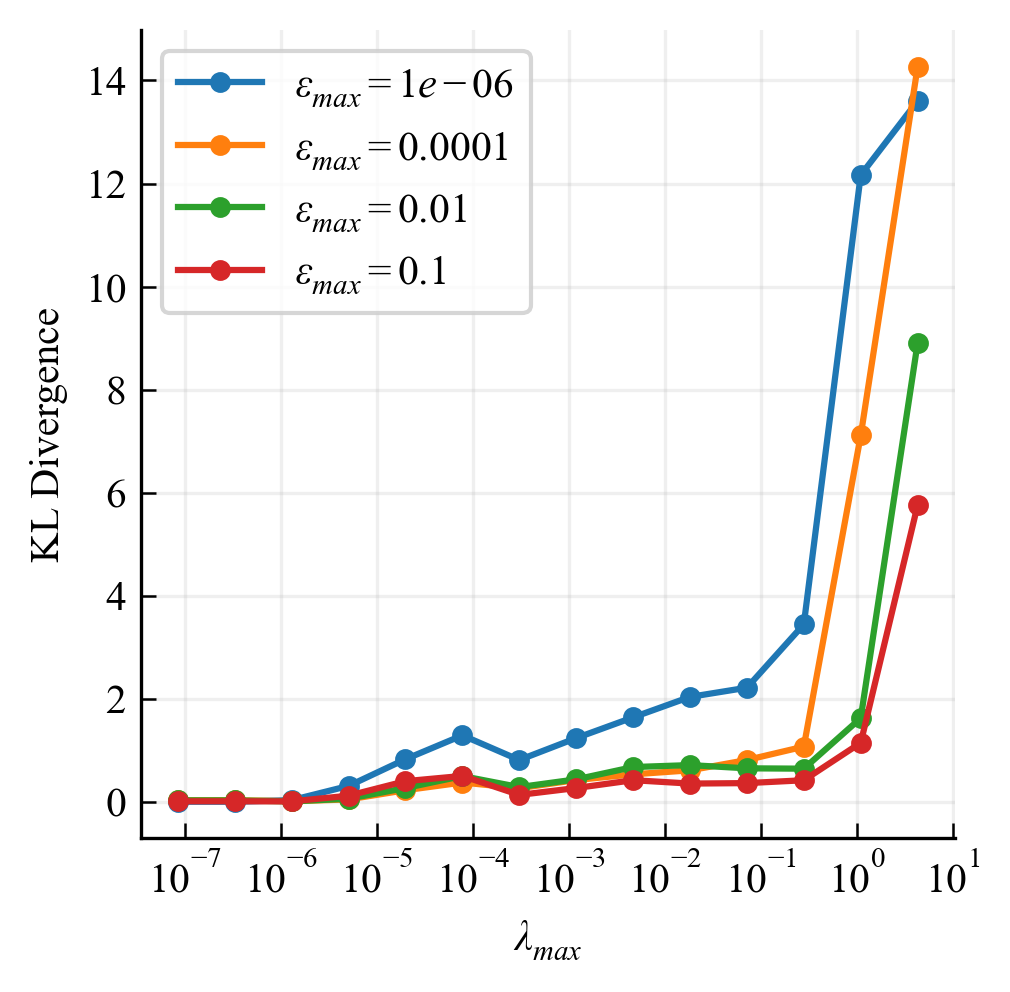

C:\Users\micha\AppData\Local\Temp\ipykernel_8056\3418829307.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10').colors


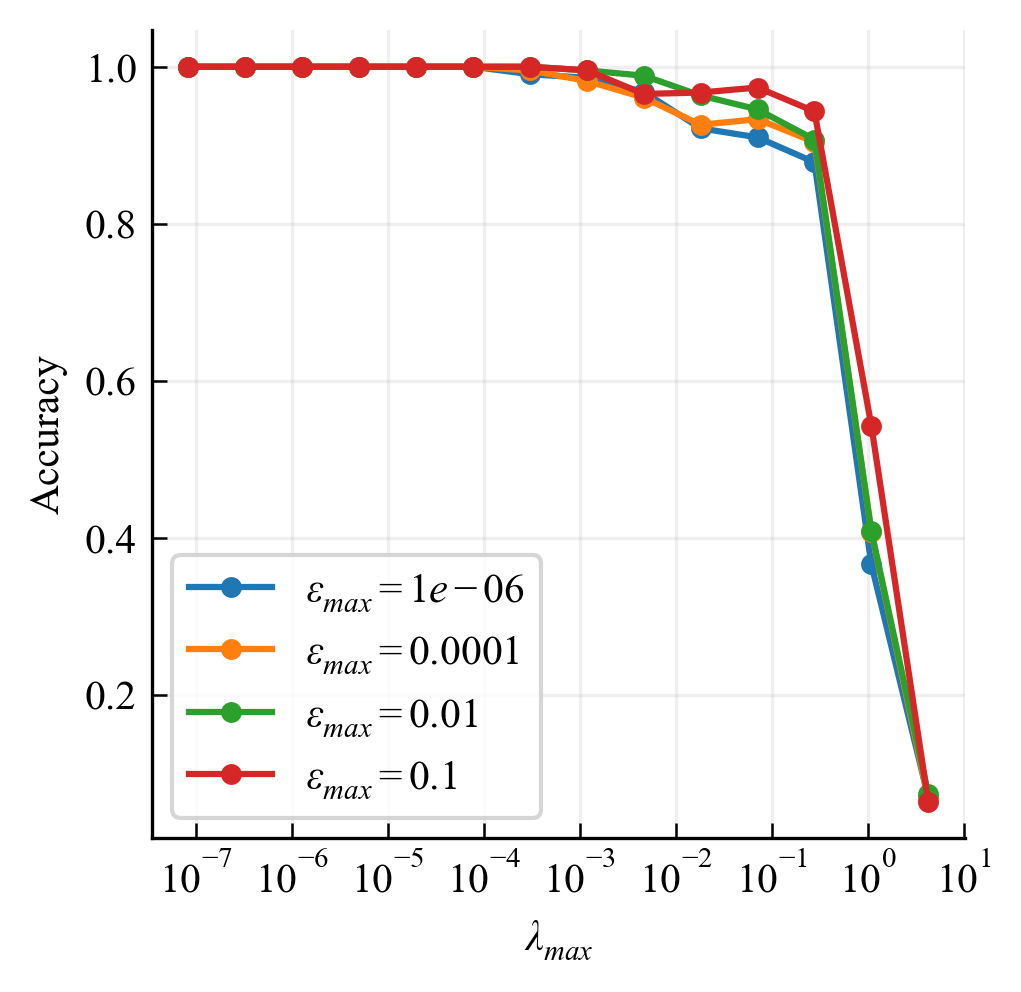

C:\Users\micha\AppData\Local\Temp\ipykernel_8056\3418829307.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10').colors


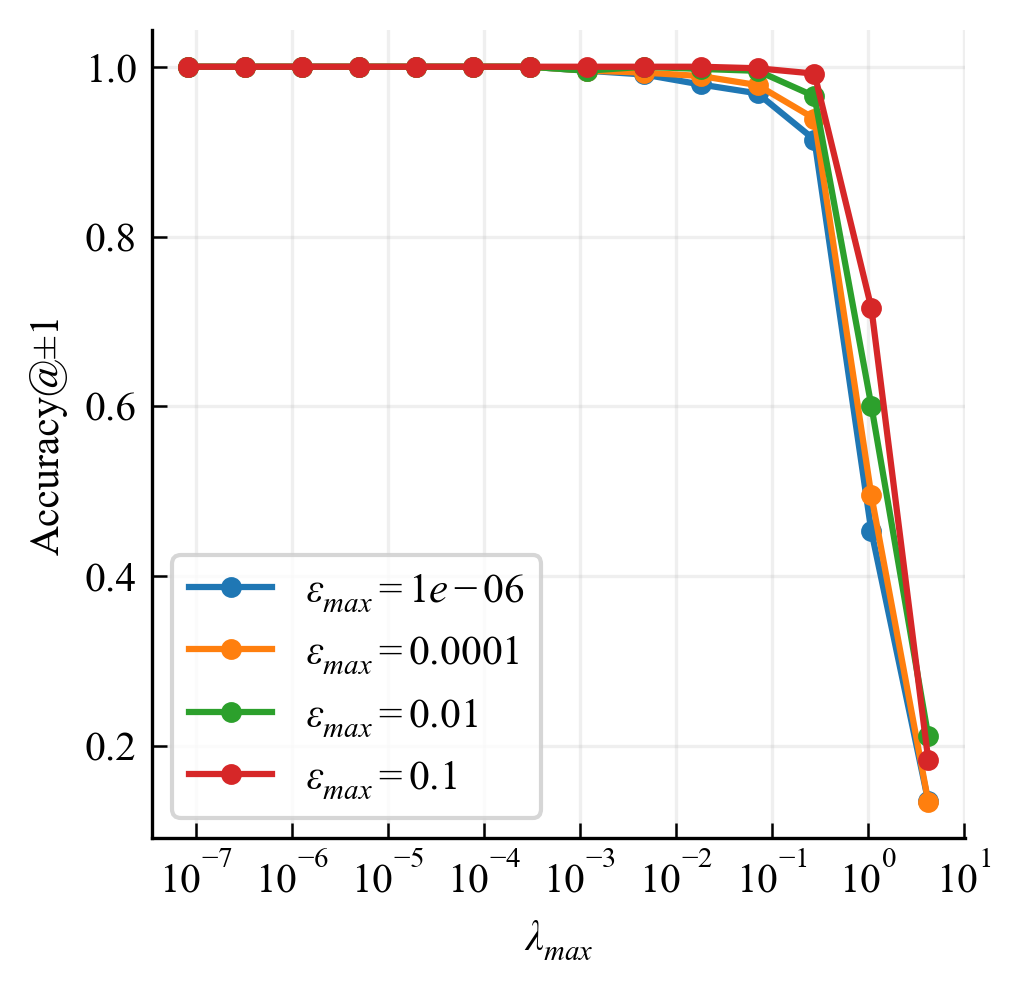

In [14]:
vizualize_result(d=15, eps_max_list=[1e-6, 0.0001, 0.01, 0.1])